C:\Users\User\AppData\Local\Temp\ipykernel_8108\2790849144.py:32: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


===== MODEL PERFORMANCE =====
Accuracy: 0.8673
ROC-AUC: 0.7833

Classification Report:

              precision    recall  f1-score   support

           0       0.87      1.00      0.93       252
           1       0.80      0.10      0.17        42

    accuracy                           0.87       294
   macro avg       0.83      0.55      0.55       294
weighted avg       0.86      0.87      0.82       294



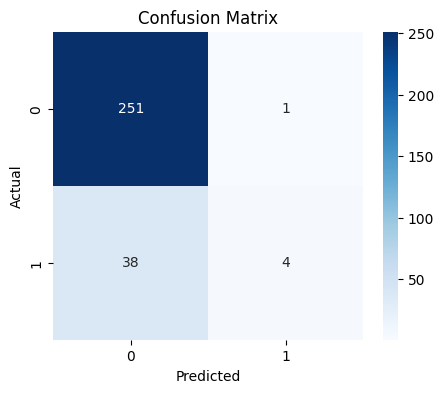

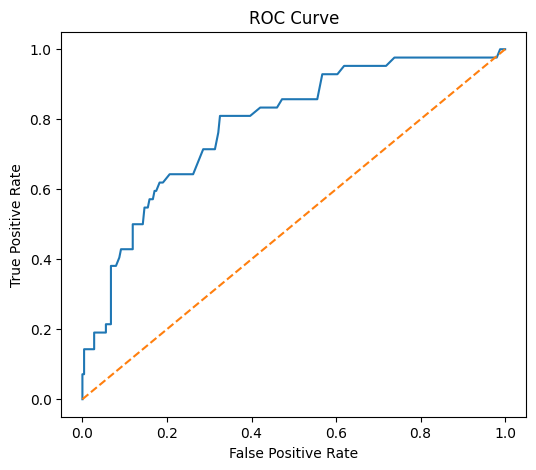


Top 10 Most Important Features:
              Feature  Importance
15      MonthlyIncome    0.073682
0                 Age    0.068223
2           DailyRate    0.056745
4    DistanceFromHome    0.053381
23  TotalWorkingYears    0.052961
18           OverTime    0.051675
16        MonthlyRate    0.050995
9          HourlyRate    0.047222
26     YearsAtCompany    0.047123
22   StockOptionLevel    0.033129


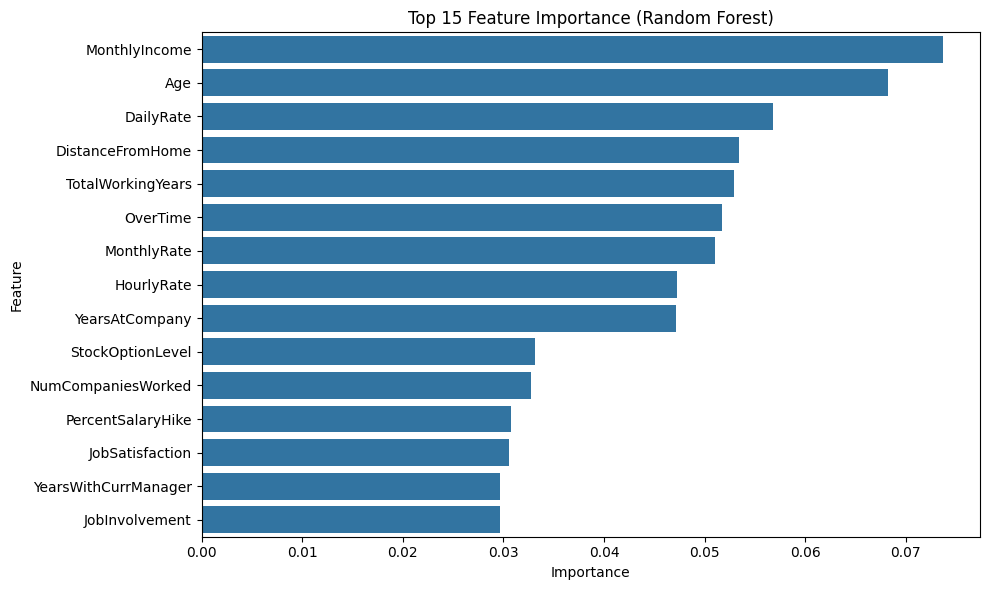

In [1]:
# ==============================
# 1. IMPORT LIBRARY
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)


# ==============================
# 2. LOAD FINAL DATASET
# ==============================
df = pd.read_csv("../data/employee_data_final.csv")


# ==============================
# 3. ENCODE CATEGORICAL COLUMNS
# ==============================
label_encoders = {}

for col in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


# ==============================
# 4. DEFINE X & y
# ==============================
X = df.drop("Attrition", axis=1)
y = df["Attrition"]


# ==============================
# 5. TRAIN TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# ==============================
# 6. TRAIN MODEL
# ==============================
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)


# ==============================
# 7. PREDICTION
# ==============================
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


# ==============================
# 8. EVALUATION METRICS
# ==============================
print("===== MODEL PERFORMANCE =====")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


# ==============================
# 9. CONFUSION MATRIX
# ==============================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# ==============================
# 10. ROC CURVE
# ==============================
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


# ==============================
# 11. FEATURE IMPORTANCE
# ==============================
feature_importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importances.head(10))


plt.figure(figsize=(10,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importances.head(15)
)
plt.title("Top 15 Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

===== MODEL PERFORMANCE =====
Accuracy: 0.8844
ROC-AUC: 0.8122

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.96      0.93       252
           1       0.64      0.43      0.51        42

    accuracy                           0.88       294
   macro avg       0.78      0.69      0.72       294
weighted avg       0.87      0.88      0.87       294



C:\Users\User\AppData\Local\Temp\ipykernel_8108\3690403744.py:32: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


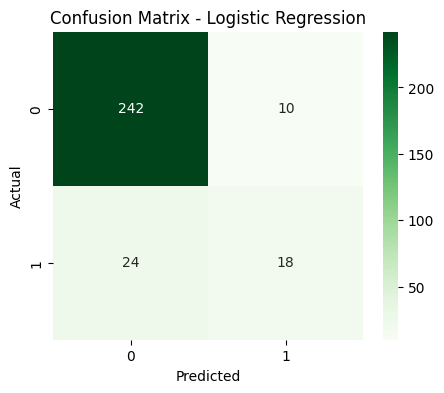

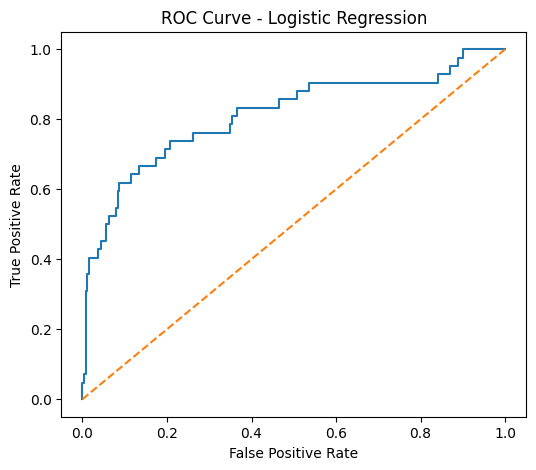


Top 10 Most Influential Features:
                    Feature  Coefficient  Abs_Coefficient
18                 OverTime     0.902041         0.902041
29     YearsWithCurrManager    -0.701549         0.701549
28  YearsSinceLastPromotion     0.686088         0.686088
26           YearsAtCompany     0.650710         0.650710
27       YearsInCurrentRole    -0.638401         0.638401
22         StockOptionLevel    -0.582299         0.582299
13          JobSatisfaction    -0.574953         0.574953
7   EnvironmentSatisfaction    -0.519804         0.519804
23        TotalWorkingYears    -0.511754         0.511754
17       NumCompaniesWorked     0.416586         0.416586


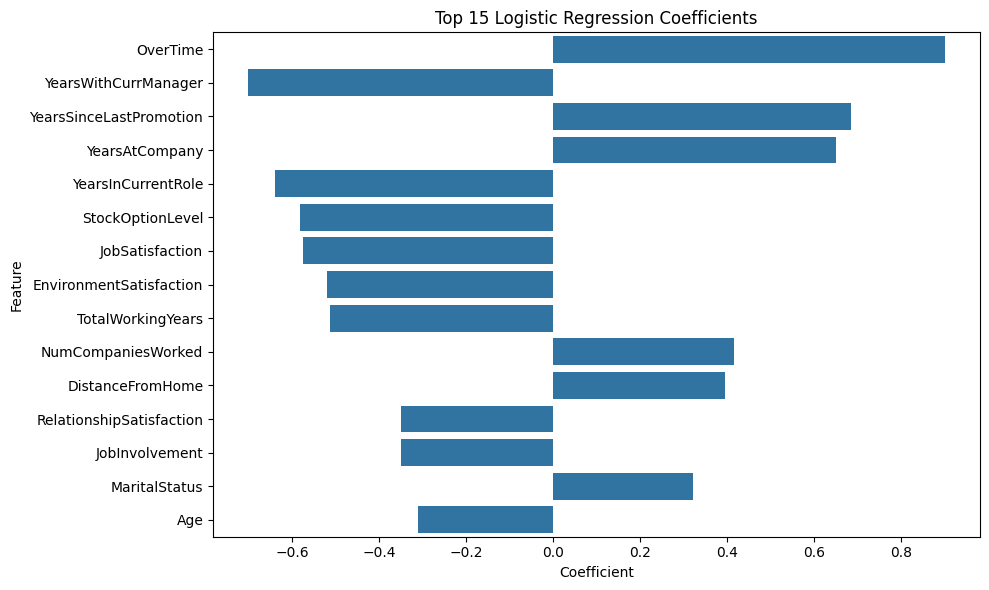

In [2]:
# ==============================
# 1. IMPORT LIBRARY
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)


# ==============================
# 2. LOAD DATA
# ==============================
df = pd.read_csv("../data/employee_data_final.csv")


# ==============================
# 3. ENCODE CATEGORICAL FEATURES
# ==============================
label_encoders = {}

for col in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


# ==============================
# 4. DEFINE X & y
# ==============================
X = df.drop("Attrition", axis=1)
y = df["Attrition"]


# ==============================
# 5. TRAIN TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# ==============================
# 6. SCALING (WAJIB untuk Logistic)
# ==============================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ==============================
# 7. TRAIN LOGISTIC REGRESSION
# ==============================
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)


# ==============================
# 8. PREDICTION
# ==============================
y_pred = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]


# ==============================
# 9. EVALUATION METRICS
# ==============================
print("===== MODEL PERFORMANCE =====")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


# ==============================
# 10. CONFUSION MATRIX
# ==============================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


# ==============================
# 11. ROC CURVE
# ==============================
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.show()


# ==============================
# 12. FEATURE IMPORTANCE (COEFFICIENT)
# ==============================
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})

coefficients["Abs_Coefficient"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    by="Abs_Coefficient", ascending=False
)

print("\nTop 10 Most Influential Features:")
print(coefficients.head(10))


plt.figure(figsize=(10,6))
sns.barplot(
    x="Coefficient",
    y="Feature",
    data=coefficients.head(15)
)

plt.title("Top 15 Logistic Regression Coefficients")
plt.tight_layout()
plt.show()